# 01 — Exploración de datos: Topic `casamarket.documento.detectado`

Este notebook lee los eventos publicados por el producer en Kafka,
los parsea y realiza análisis exploratorio.

| Servicio | URL |
|----------|-----|
| JupyterLab | http://localhost:8888 (token: `casamarket`) |
| Kafka UI | http://localhost:18085 |
| Spark UI | http://localhost:4040 (después de crear la sesión) |

## 1. Crear SparkSession

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("CasaMarket-Explorador")
    .config("spark.ui.port", "4040")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} listo — UI: http://localhost:4040")

Spark 3.5.0 listo — UI: http://localhost:4040


## 2. Leer todos los mensajes del topic (batch mode)

In [2]:
KAFKA_BROKER = "ec-kafka:9092"
TOPIC        = "casamarket.documento.detectado"

df_raw = (
    spark.read
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "earliest")
    .load()
)

print(f"Mensajes en el topic: {df_raw.count()}")
df_raw.printSchema()

Mensajes en el topic: 173
root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



## 3. Parsear JSON y definir schema

In [3]:
from pyspark.sql.functions import from_json, col, to_date, to_timestamp
from pyspark.sql.types import StructType, StructField, StringType, LongType

schema_doc = StructType([
    StructField("id",           LongType(),   True),
    StructField("filename",     StringType(), True),
    StructField("extension",    StringType(), True),
    StructField("status",       StringType(), True),
    StructField("url_file",     StringType(), True),
    StructField("created_at",   StringType(), True),
    StructField("usuario",      StringType(), True),
    StructField("detectado_en", StringType(), True),
])

df = (
    df_raw
    .select(from_json(col("value").cast("string"), schema_doc).alias("d"))
    .select("d.*")
    .withColumn("fecha",       to_date(col("created_at")))
    .withColumn("detectado_ts", to_timestamp(col("detectado_en")))
)

df.printSchema()
df.show(5, truncate=60)

root
 |-- id: long (nullable = true)
 |-- filename: string (nullable = true)
 |-- extension: string (nullable = true)
 |-- status: string (nullable = true)
 |-- url_file: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- usuario: string (nullable = true)
 |-- detectado_en: string (nullable = true)
 |-- fecha: date (nullable = true)
 |-- detectado_ts: timestamp (nullable = true)

+------+------------------------------------------------------------+---------+----------+------------------------------------------------------------+------------------------+----------------+---------------------------+----------+--------------------------+
|    id|                                                    filename|extension|    status|                                                    url_file|              created_at|         usuario|               detectado_en|     fecha|              detectado_ts|
+------+------------------------------------------------------------+-------

## 4. Análisis: documentos por extensión

In [4]:
from pyspark.sql.functions import count

por_extension = (
    df.groupBy("extension")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por extensión ===")
por_extension.show(20)

=== Documentos por extensión ===
+---------+-----+
|extension|total|
+---------+-----+
|      pdf|   85|
|     html|   78|
|     xlsx|   10|
+---------+-----+



## 5. Análisis: documentos por fecha

In [5]:
por_fecha = (
    df.groupBy("fecha")
    .agg(count("*").alias("total"))
    .orderBy("fecha", ascending=False)
)

print("=== Documentos por fecha (últimas) ===")
por_fecha.show(30)

=== Documentos por fecha (últimas) ===
+----------+-----+
|     fecha|total|
+----------+-----+
|2026-05-26|    4|
|2026-05-25|    6|
|2026-05-23|    6|
|2026-05-22|   10|
|2026-05-21|    8|
|2026-05-20|    8|
|2026-05-19|    8|
|2026-05-18|    5|
|2026-05-16|    4|
|2026-05-15|    8|
|2026-05-14|    7|
|2026-05-12|   15|
|2026-05-11|    4|
|2026-05-09|    7|
|2026-05-08|    8|
|2026-05-07|    8|
|2026-05-06|   10|
|2026-05-05|    6|
|2026-05-03|    7|
|2026-05-02|   12|
|2026-04-29|   12|
|2026-04-28|    6|
|2026-04-27|    4|
+----------+-----+



## 6. Análisis: documentos por usuario

In [6]:
por_usuario = (
    df.groupBy("usuario")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por usuario ===")
por_usuario.show(30, truncate=50)

=== Documentos por usuario ===
+----------------+-----+
|         usuario|total|
+----------------+-----+
|Admin1@tomas.com|  173|
+----------------+-----+



## 7. Análisis: documentos por estado

In [7]:
por_status = (
    df.groupBy("status")
    .agg(count("*").alias("total"))
    .orderBy(col("total").desc())
)

print("=== Documentos por estado ===")
por_status.show()

=== Documentos por estado ===
+--------------------+-----+
|              status|total|
+--------------------+-----+
|          Finalizado|  170|
|Error al generar ...|    3|
+--------------------+-----+



## 8. Visualización con matplotlib (opcional)

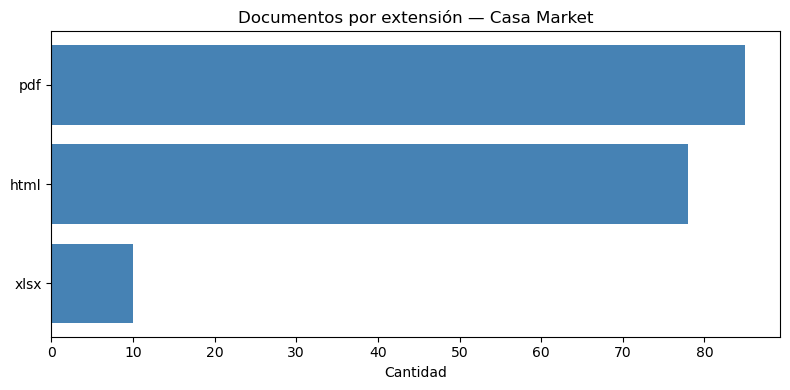

In [8]:
import matplotlib.pyplot as plt

ext_pd = por_extension.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ext_pd["extension"], ext_pd["total"], color="steelblue")
ax.set_xlabel("Cantidad")
ax.set_title("Documentos por extensión — Casa Market")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Streaming: escuchar eventos nuevos en tiempo real

> **Nota:** Ejecuta esta celda mientras el producer corre en paralelo.
> Detén la query con el botón ■ Stop o la celda siguiente.

In [9]:
from pyspark.sql.functions import window

stream_raw = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "latest")   # solo nuevos
    .load()
)

stream_docs = (
    stream_raw
    .select(from_json(col("value").cast("string"), schema_doc).alias("d"))
    .select("d.*")
    .withColumn("detectado_ts", to_timestamp(col("detectado_en")))
)

query = (
    stream_docs
    .select("id", "filename", "extension", "status", "usuario", "detectado_ts")
    .writeStream
    .outputMode("append")
    .format("console")
    .option("truncate", "false")
    .option("numRows", "20")
    .trigger(processingTime="15 seconds")
    .start()
)

print("Streaming activo — esperando mensajes nuevos (Spark UI: http://localhost:4040)")
print("Ejecuta la celda siguiente para detener.")
query.awaitTermination(timeout=120)

Streaming activo — esperando mensajes nuevos (Spark UI: http://localhost:4040)
Ejecuta la celda siguiente para detener.


False

In [10]:
# Detener el streaming
#query.stop()
#print("Streaming detenido.")